# Normalized Scanpath Saliency NSS
# Saccadeの回数


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from voluntary_fixation.envs import EYEMOVE_ROOT
from voluntary_fixation.envs import TR, MOVIE_FPS, EYEMOVE_ROOT, SAVE_ROOT, RUN_VOLUMES, RUN_IDS, MOVIE_WIDTH, MOVIE_HEIGHT, SUBJECT_IDS

from __future__ import annotations
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from tqdm import tqdm
from voluntary_fixation.dataset.bold_dataset import get_non_overlap_indices_for_concatenate_data
from voluntary_fixation.behavior.src.temporal_alignment_filtering import sacc_cnt_shift_relation_df
from voluntary_fixation.behavior.src.temporal_alignment_filtering import alignment2VOLUME as alignment2VOLUME_Original
from voluntary_fixation.behavior.src.probability import count_gaze_shift_with_saliency
from voluntary_fixation.behavior.src.data_loader import read_csvs
from voluntary_fixation.bold2visualfeat.eval_utils import get_label

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats


import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止


# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 20 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 17 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 17 # 軸だけ変更されます
# from voluntary_fixation.behavior.src.temporal_alignment_filtering import sacc_cnt_shift_relation_df, alignment2VOLUME

In [2]:


@dataclass
class Samples:
    s: str
    x: np.ndarray
    y: np.ndarray
    t: np.ndarray

    def window_mask(self, t0: float, t1: float) -> np.ndarray:
        return (self.t >= t0) & (self.t < t1)

def _stack_subjects(subjects: List[Samples], mask_list: Optional[List[np.ndarray]]=None):
    xs, ys, ts = [], [], []
    for i, s in enumerate(subjects):
        m = mask_list[i] if mask_list is not None else slice(None)
        xs.append(s.x[m]); ys.append(s.y[m]); ts.append(s.t[m])
    if len(xs)==0:
        return np.empty((0,)), np.empty((0,)), np.empty((0,))
    return np.concatenate(xs), np.concatenate(ys), np.concatenate(ts)

def _gaussian_scores_at(points_xyz: np.ndarray, train_xyz: np.ndarray, sigma_x: float, sigma_y: float, sigma_t: float) -> np.ndarray:
    if train_xyz.shape[0] == 0 or points_xyz.shape[0] == 0:
        return np.zeros((points_xyz.shape[0],), dtype=np.float64)
    px = points_xyz[:, [0]] / sigma_x; py = points_xyz[:, [1]] / sigma_y; pt = points_xyz[:, [2]] / sigma_t
    tx = train_xyz[:, 0][None, :] / sigma_x; ty = train_xyz[:, 1][None, :] / sigma_y; tt = train_xyz[:, 2][None, :] / sigma_t
    d2 = (px - tx)**2 + (py - ty)**2 + (pt - tt)**2
    return np.exp(-0.5 * d2).sum(axis=1)

def _monte_carlo_normalization_bounds(train_xyz: np.ndarray, margin: Tuple[float,float,float]):
    if train_xyz.shape[0] == 0:
        mins = np.array([0.0, 0.0, 0.0], dtype=np.float64); maxs = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    else:
        mins = train_xyz.min(axis=0); maxs = train_xyz.max(axis=0)
    sx, sy, st = margin
    mins = mins - np.array([sx, sy, st]); maxs = maxs + np.array([sx, sy, st])
    return mins, maxs

def _sample_uniform(mins: np.ndarray, maxs: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    u = rng.random((n, 3)); return mins + u * (maxs - mins)

def nss_time_extended(subjects: List[Samples], sigma_x: float = 1.2, sigma_y: float = 1.2, sigma_t: float = 26.25,
                      win_ms: float = 225.0, step_ms: float = 25.0, mc_probes: int = 4000, mc_margin: Tuple[float,float,float]=(3.0,3.0,75.0), seed: int = 0):
    rng = np.random.default_rng(seed)
    # 被験者の全サンプルの時間範囲を取得
    t_min = min(s.t.min() if s.t.size else np.inf for s in subjects); t_max = max(s.t.max() if s.t.size else -np.inf for s in subjects)
    if not np.isfinite(t_min) or not np.isfinite(t_max): raise ValueError("No samples provided.")
    # スライディングウィンドウの開始・終了時間を計算
    t0s = np.arange(t_min, t_max - win_ms + 1e-9, step_ms)
    t1s = t0s + win_ms
    # 各被験者ごとに、各ウィンドウに対する時間マスクを事前計算
    subj_masks = []
    for s in subjects:
        masks = [(s.t >= t0) & (s.t < t1) for t0, t1 in zip(t0s, t1s)]; subj_masks.append(masks)
    print('Total windows:', len(t0s))
    rows = []
    for w_idx, (t0, t1) in tqdm(enumerate(zip(t0s, t1s))):
        for k, sk in enumerate(subjects):
            test_mask = subj_masks[k][w_idx]
            # テストサンプルが存在しない場合はスキップ
            if not np.any(test_mask):
                rows.append(dict(t0=t0, t1=t1, subject=k, nss=np.nan, n_test_samples=0)); continue
            # 訓練サンプルをスタック（被験者k以外で作成）
            train_masks = [subj_masks[i][w_idx] if i != k else np.zeros_like(subj_masks[i][w_idx], dtype=bool) for i in range(len(subjects))]
            tx, ty, tt = _stack_subjects(subjects, train_masks); train_xyz = np.stack([tx, ty, tt], axis=1)
            if train_xyz.shape[0] == 0:
                rows.append(dict(t0=t0, t1=t1, subject=k, nss=np.nan, n_test_samples=int(test_mask.sum()))); continue
            # testサンプルを取得
            test_xyz = np.stack([sk.x[test_mask], sk.y[test_mask], sk.t[test_mask]], axis=1)
            # モンテカルロ法による正規化パラメータの計算
            ## mc_margin: 学習サンプルの外側に設けるサンプリング余白（x,y,t各軸）
            ## mc_probes：正規化（平均・分散）推定の精度, 混合ガウス分布Fの統計量の推定が重いのでモンテカルロを行う　（Dorr,2010の実装にはない）
            mins, maxs = _monte_carlo_normalization_bounds(train_xyz, mc_margin); probes = _sample_uniform(mins, maxs, mc_probes, rng)
            F_probes = _gaussian_scores_at(probes, train_xyz, sigma_x, sigma_y, sigma_t); mu = F_probes.mean(); sd = F_probes.std(ddof=0)
            if sd == 0.0:
                print(f"[warn] Window {t0:.1f}-{t1:.1f}ms, subject {k}: sd=0 (train_samples={len(train_xyz)})")
                rows.append(dict(t0=t0, t1=t1, subject=k, nss=np.nan, n_test_samples=int(test_mask.sum()))); continue
            # テストサンプルに対するスコア計算
            F_test = _gaussian_scores_at(test_xyz, train_xyz, sigma_x, sigma_y, sigma_t)
            # 正規化スコア計算
            nss_vals = (F_test - mu) / sd; nss = float(nss_vals.mean())
            rows.append(dict(t0=t0, t1=t1, subject=k, nss=nss, n_test_samples=int(test_mask.sum())))
    df = pd.DataFrame(rows)
    meta = dict(sigma_x=sigma_x, sigma_y=sigma_y, sigma_t=sigma_t, win_ms=win_ms, step_ms=step_ms, mc_probes=mc_probes, mc_margin=mc_margin, seed=seed)
    return df, meta


def get_eyetrack_df(sub_id, run_id):
    eyetrack_fn = f'sub-{sub_id}/sub-{sub_id}_task-movie_run-{run_id}_events.tsv'
    eyetrack_path = os.path.join('../../', EYEMOVE_ROOT, eyetrack_fn)
    eyetrack = pd.read_table(eyetrack_path)
    return eyetrack

def get_saliency_df(run_id):
    # movieのsaliencyのデータを取得
    saliency_path = os.path.join('../../', SAVE_ROOT, 'saliency/deepgaze2e_predict', f'segment{run_id}.csv')
    saliency_df = pd.read_csv(saliency_path)
    return saliency_df

def find_idx_of_specific_onset_offset(df, start, end, offset=False)->np.ndarray:
    onsets = df['t0'].values
    if offset:
        offsets = df['t1'].values
        idx = np.where((start <= offsets) & (offsets<=end))[0]
        # idx = np.where((start <= onsets) & (offsets<=end))[0]

    else:
        idx = np.where((start <= onsets) & (onsets<=end))[0]
    return idx

def alignment2VOLUME(df:pd.DataFrame, run_id:int, agg:str='sum')->pd.DataFrame:
    num_sample_per_run = RUN_VOLUMES[run_id-1]
    columns = list(df.columns)
    new_df = {col:[] for col in columns}
    for i in range(num_sample_per_run):
        onset = i * TR
        offset = onset + TR
        idx = find_idx_of_specific_onset_offset(df, onset, offset)
        if agg == 'sum':
            agg_df = df.iloc[idx].sum()
        elif agg == 'mean':
            agg_df = df.iloc[idx].mean()
        else:
            raise ValueError('agg should be sum or mean')
        for col in columns:
            new_df[col].append(agg_df[col])
    new_df = pd.DataFrame(new_df)
    return new_df




In [3]:

FIXATION_LABEL = ['PURS', 'FIXA']
resample_fs = 25 # 1000Hz以下
fs_ms = 1000 / resample_fs # ms

win_ms = 250 # 2000
step_ms = win_ms / 2
sigma_x = 100 # 視野角の半径100の1/3 # 100
sigma_y = 100 # 視野角の半径100の1/3 # 100
sigma_t = fs_ms * 4 # 4フレーム分の時間幅 # 500

for run_id in RUN_IDS:
    df_path = os.path.join('../../', SAVE_ROOT, 'NSS', f'check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv')
    if os.path.exists(df_path):
        print(f'File already exists: {df_path}, skipping computation.')
        continue
    saliency_df = get_saliency_df(run_id=run_id)
    # create subject list
    subj_list = []
    for sub_id in SUBJECT_IDS:
        eyetrack = get_eyetrack_df(sub_id, run_id)
        eyetrack_fixations = eyetrack[eyetrack['label'].isin(FIXATION_LABEL)]
        xs, ys, ts = [], [], []
        for i, row in eyetrack_fixations.iterrows():
            duration = row['duration'] * 1000
            t_Start = row['onset'] * 1000
            t_End = t_Start + duration
            n_points = int(np.ceil(duration / fs_ms))
            t = np.linspace(t_Start, t_End, n_points)
            if n_points > 1:
                x = np.interp(t, [t_Start, t_End], [row['start_x'], row['end_x']])
                y = np.interp(t, [t_Start, t_End], [row['start_y'], row['end_y']])
            else:
                x = np.array([row['start_x']])
                y = np.array([row['start_y']])
            assert len(x) == len(y) == len(t), f"Length mismatch: {len(x)}, {len(y)}, {len(t)}"
            xs += x.tolist()
            ys += y.tolist()
            ts += t.tolist()
        subj_list.append(Samples(s=sub_id, x=np.array(xs), y=np.array(ys), t=np.array(ts)))

        # print('max duration:', duration.max(), 'min duration:', duration.min())
        print('subj:', sub_id, 'n_fixations:', len(eyetrack_fixations), 'n_points:', len(xs))


    print('Computing NSS scores with parameters:')
    print(f'win_ms: {win_ms}, step_ms: {step_ms}, sigma_x: {sigma_x}, sigma_y: {sigma_y}, sigma_t: {sigma_t}')
    df, meta = nss_time_extended(
        subj_list,
        sigma_x=sigma_x, sigma_y=sigma_y, sigma_t=sigma_t,
        # win_ms=225.0, step_ms=75.0,
        win_ms=win_ms, step_ms=step_ms,
        mc_probes=4000, mc_margin=(30, 30, 75.0), seed=0
    )
    os.makedirs(os.path.dirname(df_path), exist_ok=True)
    df.to_csv(df_path, index=False)
    df['nss'].plot.hist(bins=50, range=(-1, 1))


File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run1_win250_step125_100_100_160.0.csv, skipping computation.
File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run2_win250_step125_100_100_160.0.csv, skipping computation.
File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run3_win250_step125_100_100_160.0.csv, skipping computation.
File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run4_win250_step125_100_100_160.0.csv, skipping computation.
File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run5_win250_step125_100_100_160.0.csv, skipping computation.
File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run6_win250_step125_100_100_160.0.csv, skipping computation.
File already exists: ../../../../results/voluntary_fixation/NSS/check_nss_saliency_run7_win250_step125_100_100_160.0.csv, skipping compu

sbj01 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj02 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1141963/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1141963/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1141963/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

sbj03 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj04 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1141963/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1141963/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1141963/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

sbj06 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj10 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


...

sbj16 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj17 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1141963/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1141963/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1141963/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

sbj18 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')
sbj19 Index(['t0', 't1', 'subject', 'nss', 'n_test_samples'], dtype='object')


/tmp/ipykernel_1141963/983102892.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df.dropna(inplace=True, axis=0)
/tmp/ipykernel_1141963/983102892.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbj_df['t0'] = sbj_df['t0'] / 1000.0
/tmp/ipykernel_1141963/983102892.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

<Axes: ylabel='Frequency'>

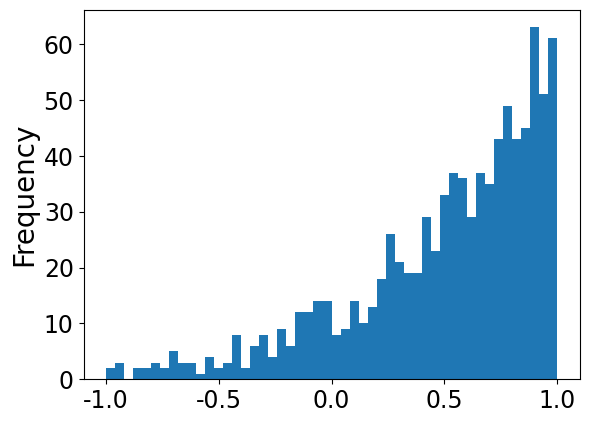

In [4]:
# FIXATION_LABEL = ['PURS', 'FIXA']
# resample_fs = 25 # 1000Hz以下
# fs_ms = 1000 / resample_fs # ms

# win_ms = 250 # 2000
# step_ms = win_ms / 2
# sigma_x = 100 # 33.3 # 視野角の半径100の1/3 # 100
# sigma_y = 100 # 33.3 # 視野角の半径100の1/3 # 100
# sigma_t = fs_ms * 4 # 4フレーム分の時間幅 # 500

sbj_df_list = {
    sbj_id: [] for sbj_id in SUBJECT_IDS
}

# NSS df の用意
for run_id in RUN_IDS:
    original_df = pd.read_csv(os.path.join('../../', SAVE_ROOT, 'NSS', f'check_nss_saliency_run{run_id}_win{int(win_ms)}_step{int(step_ms)}_{sigma_x}_{sigma_y}_{sigma_t}.csv'))

    for s, sbj_id in enumerate((SUBJECT_IDS)):
        sbj_df = original_df[original_df['subject'] == s]
        print(f'sbj{sbj_id}', sbj_df.columns)
        sbj_df.dropna(inplace=True, axis=0)
        sbj_df['t0'] = sbj_df['t0'] / 1000.0
        sbj_df['t1'] = sbj_df['t1'] / 1000.0
        aligned_df = alignment2VOLUME(sbj_df, run_id=run_id, agg='mean')
        sbj_df_list[sbj_id].append(aligned_df)
for sbj_id in SUBJECT_IDS:
    sbj_df_list[sbj_id] = pd.concat(sbj_df_list[sbj_id], axis=0, ignore_index=True)
sbj_df_list['01']['nss'].plot.hist(bins=50, range=(-1, 1))

non overlap test indices 3598 815
Index(['iou_q', 'saliency_TR_q', 'iou_th', 'sal_upper_th', 'sal_lower_th'], dtype='object')
    iou_q  saliency_TR_q    iou_th  sal_upper_th  sal_lower_th
42    0.5            0.7  0.312469   1057.732985    424.850136
424.8501357814248 1057.7329848865415
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj01  th2:  0.31246855875
sbj01 zero: 210
sbj01 saliency_th_upper_train:  1057.7329848865415
sbj01 saliency_th_lower_train:  424.8501357814248
label1:: gaze shift with saliency shift and small iou
	 TRAIN:: 408. TEST:: 137
label2:: gaze shift without saliency shift and small iou
	 TRAIN:: 259. TEST:: 98
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.5-sal_q0.9.csv is already exist
sbj02  th2:  0.31246855875
sbj02 zero: 28
sbj02 sal

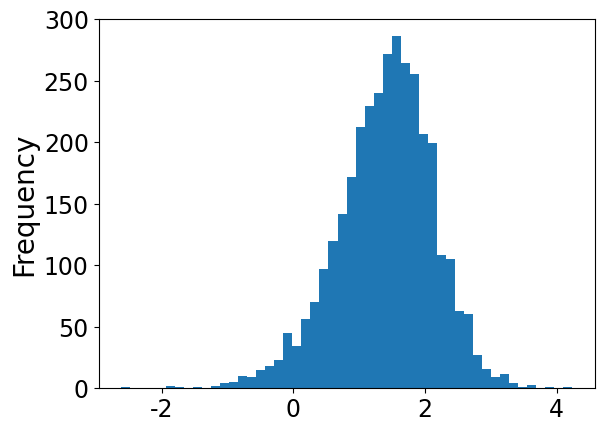

nss_all_sbj shape: (12, 815)
max w_sal_in_tests 813
max wo_sal_in_tests 814
nss_dict w_sal_gaze shape: (12,)
nss_dict wo_sal_gaze shape: (12,)


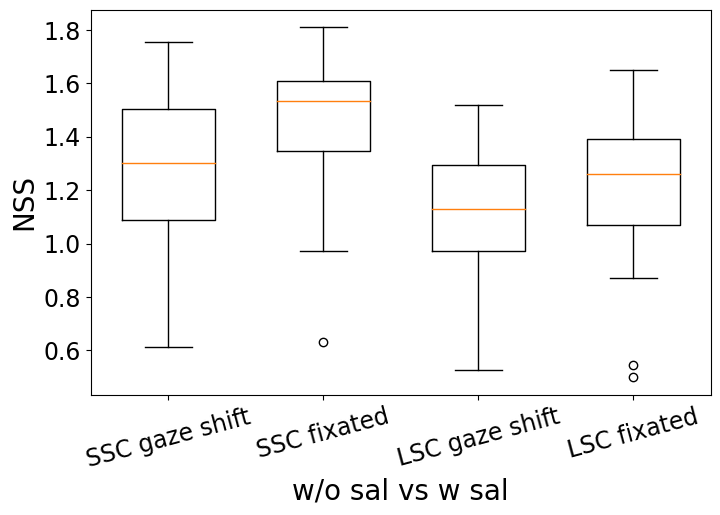

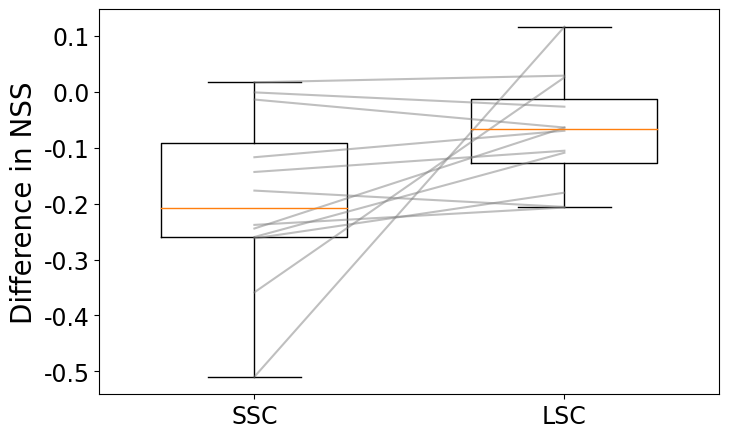

TtestResult(statistic=-2.0980535548704693, pvalue=0.05980148669051105, df=11)
/home/kazu/shared_response/figures/fig1/NSS_difference.pdf


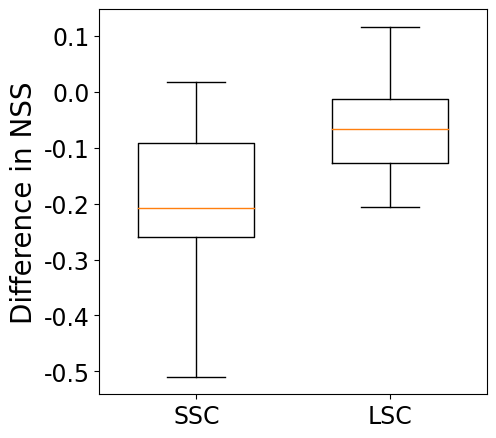

                  sum_sq    df         F    PR(>F)
C(sal)          0.443666   1.0  3.567470  0.065525
C(gaze)         0.208511   1.0  1.676615  0.202129
C(sal):C(gaze)  0.043670   1.0  0.351145  0.556499
Residual        5.472035  44.0       NaN       NaN
sal: eta2= 0.07193172511727093 partial eta2= 0.07499811222028101
gaze: eta2= 0.03380597356862493 partial eta2= 0.03670620186285855
inter: eta2= 0.007080216926458818 partial eta2= 0.007917382759012152
nss_all_sbj shape: (12, 815)
max w_sal_in_tests 813
sbj: 01 len wo_sal gaze / nogaze: 98 195 len w_sal gaze /nogaze: 137 139
sbj: 02 len wo_sal gaze / nogaze: 117 176 len w_sal gaze /nogaze: 151 125
sbj: 03 len wo_sal gaze / nogaze: 122 171 len w_sal gaze /nogaze: 137 139
sbj: 04 len wo_sal gaze / nogaze: 116 177 len w_sal gaze /nogaze: 141 135
sbj: 06 len wo_sal gaze / nogaze: 109 184 len w_sal gaze /nogaze: 132 144
sbj: 10 len wo_sal gaze / nogaze: 123 170 len w_sal gaze /nogaze: 144 132
sbj: 14 len wo_sal gaze / nogaze: 127 166 len w_sa

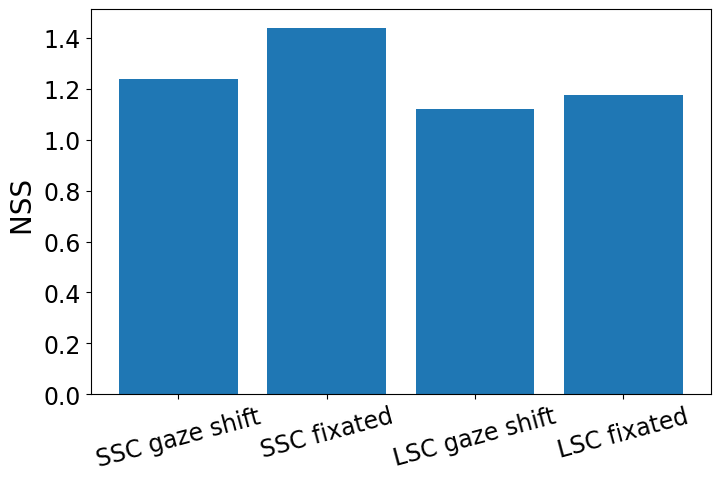

                     sum_sq      df          F        PR(>F)
C(sal)            64.007149     1.0  96.847025  1.067409e-22
C(gaze)           27.892551     1.0  42.203264  8.817381e-11
C(sal):C(gaze)     8.463970     1.0  12.806543  3.478546e-04
Residual        4421.486629  6690.0        NaN           NaN
sal: eta2= 0.01415507920741489 partial eta2= 0.014269811154613675
gaze: eta2= 0.006168393280587106 partial eta2= 0.006268863558950904
inter: eta2= 0.001871793513454089 partial eta2= 0.0019106240283287437


In [ ]:

prefix_dir = '../../'
gaze_shift_label = ['FIXA', 'PURS']

non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data('segment', jupyter=True)
print('non overlap test indices', non_overlap_test_indices.max(), len(non_overlap_test_indices))
# get label
frame_offset = 0
delay = 0
mask_offset = 0
n_components = 250
modality = 'masked_image'
sampling_mode = 'segment'
remove_str = '-remove_brightness' #+'-remove_empty_eyetrack'
saliency_label = 'avg_shift_norm'

remove_empty_eyetrack = False
saliency_TR_q = 0.7
iou_q = 0.5

# threshold取得
grand_quantile_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', 'grand_quantiles.csv')
grand_quantiles_df = pd.read_csv(grand_quantile_path)
print(grand_quantiles_df.columns)
target_th = grand_quantiles_df.query(f'saliency_TR_q=={saliency_TR_q}').query(f'iou_q=={iou_q}')
sal_upper_th = target_th['sal_upper_th'].values[0]
sal_lower_th = target_th['sal_lower_th'].values[0]
print(target_th)
print(sal_lower_th, sal_upper_th)

# label取得
w_sal_in_tests = {}
wo_sal_in_tests = {}

# labelの用意
saliency_dir = os.path.join(prefix_dir, SAVE_ROOT, 'saliency', 'deepgaze2e_predict')
eyemovement_dir = os.path.join(prefix_dir, EYEMOVE_ROOT)
eyemovement_q = 0.5
saliency_q = 0.9
gaze_shift_label = ['FIXA', 'PURS']
use_large_cnt = False
if use_large_cnt:
    lc_str = '_large'
else:
    lc_str = ''



# saliency

sal_df_sbj = {}
eye_df_sbj = {}
dummy_sbj_id = SUBJECT_IDS[0]
saliency_eyetrack_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                    f'{dummy_sbj_id}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
if os.path.exists(saliency_eyetrack_path):
    print(f'{saliency_eyetrack_path} is already exist')
    saliency_eyetrack_df = pd.read_csv(saliency_eyetrack_path)
    for label in ['max_shift_norm', 'avg_shift_norm']:
        if f'SACC_cnt_with{lc_str}_lower_sal_{label}' in saliency_eyetrack_df.columns:
            saliency_eyetrack_df = saliency_eyetrack_df.rename(columns={f'SACC_cnt_with{lc_str}_lower_sal_{label}':f'SACC_cnt{lc_str}_with_lower_sal_{label}'})


for sbj in SUBJECT_IDS:
    iou_path = os.path.join(prefix_dir, SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                            f'sub-{sbj}.csv')
    pred_and_gt_dir = os.path.join(prefix_dir, SAVE_ROOT, 'bold2feat_strict_ree2', f'delay{delay}-fo{frame_offset}-mo{mask_offset}',
                                    f'pca{n_components}-{modality}-{sampling_mode}{remove_str}', sbj)

    saliency_eyetrack_path = os.path.join(prefix_dir, SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                            f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    eye_tracking_exist_flag_dir = os.path.join(prefix_dir, SAVE_ROOT, 'features', f'pooled_{modality}-tr{TR}-fo{frame_offset}-mo{mask_offset}', sbj)
    w_sal_in_train, w_sal_in_test, wo_sal_in_train, wo_sal_in_test = get_label(iou_path, saliency_eyetrack_path, EYEMOVE_ROOT, saliency_dir, sampling_mode, eye_tracking_exist_flag_dir,
                                                                                saliency_label,
                                                                                iou_q, eyemovement_q, saliency_q, sbj, gaze_shift_label, delay,
                                                                                remove_empty_eyetrack, use_large_cnt=use_large_cnt,
                                                                                saliency_TR_q=saliency_TR_q, jupyter=True)
    w_sal_in_tests[sbj] = w_sal_in_test
    wo_sal_in_tests[sbj] = wo_sal_in_test


# saliency testデータのみ
saliency_shift = saliency_eyetrack_df['avg_shift_norm'].to_numpy()
saliency_shift = saliency_shift[non_overlap_test_indices]

sbj_df_list['01']['nss'].plot.hist(bins=50)
plt.show()
nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]

wo_sal_indices = np.where(saliency_shift <= sal_lower_th)[0]
w_sal_indices = np.where(saliency_shift > sal_upper_th)[0]

print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
print('max wo_sal_in_tests', max(wo_sal_in_test))
nss_dict = {'sbj':[], 'w_sal_gaze':[], 'wo_sal_gaze':[], 'w_sal_no_gaze':[], 'wo_sal_no_gaze':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    wo_sal_in_test_nogaze = [i for i in wo_sal_indices if not i in wo_sal_in_test]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if not i in w_sal_in_test]

    sbj_wo_sal_nogaze = nss_all_sbj[s, wo_sal_in_test_nogaze]
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    sbj_w_sal_nogaze = nss_all_sbj[s, w_sal_in_test_nogaze]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal_gaze'].append(np.nanmean(sbj_w_sal))
    nss_dict['wo_sal_gaze'].append(np.nanmean(sbj_wo_sal))
    nss_dict['w_sal_no_gaze'].append(np.nanmean(sbj_w_sal_nogaze))
    nss_dict['wo_sal_no_gaze'].append(np.nanmean(sbj_wo_sal_nogaze))
print('nss_dict w_sal_gaze shape:', np.array(nss_dict['w_sal_gaze']).shape)
print('nss_dict wo_sal_gaze shape:', np.array(nss_dict['wo_sal_gaze']).shape)

wo_sal_gaze_sbj = np.array(nss_dict['wo_sal_gaze'])
w_sal_gaze_sbj = np.array(nss_dict['w_sal_gaze'])
wo_sal_no_gaze_sbj = np.array(nss_dict['wo_sal_no_gaze'])
w_sal_no_gaze_sbj = np.array(nss_dict['w_sal_no_gaze'])

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.boxplot([wo_sal_gaze_sbj, wo_sal_no_gaze_sbj, w_sal_gaze_sbj, w_sal_no_gaze_sbj], positions=[0, 1, 2, 3], widths=0.6)
axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS')
axes.set_xticks([0, 1, 2, 3])
axes.set_xticklabels(['SSC gaze shift', 'SSC fixated', 'LSC gaze shift', 'LSC fixated'], rotation=15)
plt.show()


wo_sal_ratio = wo_sal_gaze_sbj-wo_sal_no_gaze_sbj # wo_sal_gaze_sbj/wo_sal_no_gaze_sbj
w_sal_ratio = w_sal_gaze_sbj-w_sal_no_gaze_sbj # w_sal_gaze_sbj/w_sal_no_gaze_sbj

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.boxplot([wo_sal_ratio, w_sal_ratio], positions=[0, 1], widths=0.6)
for i in range(len(wo_sal_ratio)):
    axes.plot([0, 1], [wo_sal_ratio[i], w_sal_ratio[i]], color='gray', alpha=0.5)
# axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('Difference in NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['SSC', 'LSC'], rotation=0)
plt.show()
print(stats.ttest_rel(wo_sal_ratio, w_sal_ratio))

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
plt.boxplot([wo_sal_ratio, w_sal_ratio], positions=[0, 1], widths=0.6)
axes.set_ylabel('Difference in NSS')
axes.set_xticks([0, 1])
axes.set_xticklabels(['SSC', 'LSC'], rotation=0)
savepath = os.path.join('/home/kazu/shared_response/figures', 'fig1', 'NSS_difference.pdf')
plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)
plt.show()




# ==== データ整形 ====
a1b1 =nss_dict['w_sal_gaze']
a1b2 =nss_dict['w_sal_no_gaze']
a2b1 =nss_dict['wo_sal_gaze']
a2b2 =nss_dict['wo_sal_no_gaze']
y = np.concatenate([a1b1, a1b2, a2b1, a2b2])
A = (["w_sal"] * len(a1b1)) + (["w_sal"] * len(a1b2)) + (["wo_sal"] * len(a2b1)) + (["wo_sal"] * len(a2b2))
B = (["gaze"] * len(a1b1)) + (["no_gaze"] * len(a1b2)) + (["gaze"] * len(a2b1)) + (["no_gaze"] * len(a2b2))


df1 = pd.DataFrame({"y": y, "sal": A, "gaze": B})

# ==== 二元配置分散分析（交互作用を含む一般的なモデル）====
# 対応なしの独立群デザインなので OLS でOK
model = smf.ols("y ~ C(sal) * C(gaze)", data=df1).fit()
anova_table = anova_lm(model, typ=2)  # typ=2 が一般的（不均衡デザインにも比較的頑健）
print(anova_table)
SS_sal = anova_table['sum_sq']['C(sal)']
SS_gaze = anova_table['sum_sq']['C(gaze)']
SS_inter = anova_table['sum_sq']['C(sal):C(gaze)']
SS_res = anova_table['sum_sq']['Residual']

eta2_sal = SS_sal / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_gaze = SS_gaze / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_inter = SS_inter / (SS_sal + SS_gaze + SS_inter + SS_res)

partial_eta2_sal = SS_sal / (SS_sal + SS_res)
partial_eta2_gaze = SS_gaze / (SS_gaze + SS_res)
partial_eta2_inter = SS_inter / (SS_inter + SS_res)


print('sal: eta2=', eta2_sal, 'partial eta2=', partial_eta2_sal)
print('gaze: eta2=', eta2_gaze, 'partial eta2=', partial_eta2_gaze)
print('inter: eta2=', eta2_inter, 'partial eta2=', partial_eta2_inter)


# 被験者 flatten

nss_all_sbj = np.stack([sbj_df_list[sbj_id]['nss'].to_numpy() for sbj_id in SUBJECT_IDS], axis=0)
nss_all_sbj = nss_all_sbj[:, non_overlap_test_indices]
print('nss_all_sbj shape:', nss_all_sbj.shape)  # (num_subjects, num_timepoints
print('max w_sal_in_tests', max(w_sal_in_test))
nss_dict = {'sbj':[], 'w_sal_gaze':[], 'wo_sal_gaze':[], 'w_sal_no_gaze':[], 'wo_sal_no_gaze':[]}
for s, sbj_id in enumerate((SUBJECT_IDS)):
    w_sal_in_test = w_sal_in_tests[sbj_id]
    wo_sal_in_test = wo_sal_in_tests[sbj_id]
    wo_sal_in_test_nogaze = [i for i in wo_sal_indices if not i in wo_sal_in_test]
    w_sal_in_test_nogaze = [i for i in w_sal_indices if not i in w_sal_in_test]
    print('sbj:', sbj_id, 'len wo_sal gaze / nogaze:', len(wo_sal_in_test), len(wo_sal_in_test_nogaze), 'len w_sal gaze /nogaze:', len(w_sal_in_test), len(w_sal_in_test_nogaze))

    sbj_wo_sal_nogaze = nss_all_sbj[s, wo_sal_in_test_nogaze]
    sbj_wo_sal = nss_all_sbj[s, wo_sal_in_test]
    sbj_w_sal_nogaze = nss_all_sbj[s, w_sal_in_test_nogaze]
    sbj_w_sal = nss_all_sbj[s, w_sal_in_test]
    nss_dict['sbj'].append(sbj_id)
    nss_dict['w_sal_gaze'].append(sbj_w_sal)
    nss_dict['wo_sal_gaze'].append(sbj_wo_sal)
    nss_dict['w_sal_no_gaze'].append(sbj_w_sal_nogaze)
    nss_dict['wo_sal_no_gaze'].append(sbj_wo_sal_nogaze)

w_sal_gaze_mean= np.nanmean(np.concatenate(nss_dict['w_sal_gaze'], axis=0))
wo_sal_gaze_mean = np.nanmean(np.concatenate(nss_dict['wo_sal_gaze'], axis=0))
w_sal_no_gaze_mean = np.nanmean(np.concatenate(nss_dict['w_sal_no_gaze'], axis=0))
wo_sal_no_gaze_mean = np.nanmean(np.concatenate(nss_dict['wo_sal_no_gaze'], axis=0))


fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 5))
plt.bar([0,1,2,3], [wo_sal_gaze_mean, wo_sal_no_gaze_mean, w_sal_gaze_mean, w_sal_no_gaze_mean])
# axes.set_xlabel('w/o sal vs w sal')
axes.set_ylabel('NSS ')
axes.set_xticks([0, 1, 2, 3])
axes.set_xticklabels(['SSC gaze shift', 'SSC fixated', 'LSC gaze shift', 'LSC fixated'], rotation=15)
plt.show()



# from scipy import stats
# t_stat, p_val = stats.ttest_ind(nss_dict['wo_sal_gaze'], nss_dict['w_sal_gaze'], equal_var=False)

# print("t値:", t_stat)
# print("p値:", p_val)




# ==== データ整形 ====
a1b1 = np.concatenate(nss_dict['w_sal_gaze'])
a1b2 = np.concatenate(nss_dict['w_sal_no_gaze'])
a2b1 = np.concatenate(nss_dict['wo_sal_gaze'])
a2b2 = np.concatenate(nss_dict['wo_sal_no_gaze'])
y = np.concatenate([a1b1, a1b2, a2b1, a2b2])
A = (["w_sal"] * len(a1b1)) + (["w_sal"] * len(a1b2)) + (["wo_sal"] * len(a2b1)) + (["wo_sal"] * len(a2b2))
B = (["gaze"] * len(a1b1)) + (["no_gaze"] * len(a1b2)) + (["gaze"] * len(a2b1)) + (["no_gaze"] * len(a2b2))

df = pd.DataFrame({"y": y, "sal": A, "gaze": B})

# ==== 二元配置分散分析（交互作用を含む一般的なモデル）====
# 対応なしの独立群デザインなので OLS でOK
model = smf.ols("y ~ C(sal) * C(gaze)", data=df).fit()
anova_table = anova_lm(model, typ=2)  # typ=2 が一般的（不均衡デザインにも比較的頑健）
print(anova_table)
SS_sal = anova_table['sum_sq']['C(sal)']
SS_gaze = anova_table['sum_sq']['C(gaze)']
SS_inter = anova_table['sum_sq']['C(sal):C(gaze)']
SS_res = anova_table['sum_sq']['Residual']

eta2_sal = SS_sal / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_gaze = SS_gaze / (SS_sal + SS_gaze + SS_inter + SS_res)
eta2_inter = SS_inter / (SS_sal + SS_gaze + SS_inter + SS_res)

partial_eta2_sal = SS_sal / (SS_sal + SS_res)
partial_eta2_gaze = SS_gaze / (SS_gaze + SS_res)
partial_eta2_inter = SS_inter / (SS_inter + SS_res)


print('sal: eta2=', eta2_sal, 'partial eta2=', partial_eta2_sal)
print('gaze: eta2=', eta2_gaze, 'partial eta2=', partial_eta2_gaze)
print('inter: eta2=', eta2_inter, 'partial eta2=', partial_eta2_inter)
